In [1]:
import pandas as pd
import numpy as np

print("Python is working!")
print("Pandas version:", pd.__version__)

Python is working!
Pandas version: 3.0.1


In [2]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path("../data/raw")

accounts = pd.read_csv(DATA_PATH / "accounts.csv")

print("Rows:", accounts.shape[0])
print("Columns:", accounts.shape[1])

Rows: 30000
Columns: 11


In [3]:
accounts.head()

,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2


In [4]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   account_id          30000 non-null  str    
 1   borrower_id         29545 non-null  str    
 2   loan_type           30000 non-null  str    
 3   principal_amount    30000 non-null  float64
 4   outstanding_amount  30000 non-null  float64
 5   dpd                 30000 non-null  int64  
 6   risk_segment        30000 non-null  str    
 7   status              30000 non-null  str    
 8   opened_at           30000 non-null  str    
 9   timezone            30000 non-null  str    
 10  schema_version      30000 non-null  str    
dtypes: float64(2), int64(1), str(8)
memory usage: 2.5 MB


In [5]:
data_dictionary = pd.read_csv(DATA_PATH / "data_dictionary.csv")

print("Rows:", data_dictionary.shape[0])
print("Columns:", data_dictionary.shape[1])

data_dictionary

Rows: 143
Columns: 3


,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
...,...,...,...
138,account_status_history,event_at,datetime64[ns]
139,account_status_history,status,object
140,account_status_history,changed_by,object
141,account_status_history,source,object


In [6]:
data_dictionary.columns.tolist()

['dataset', 'column', 'dtype']

In [7]:
# Load all datasets

datasets = {
    "borrowers": pd.read_csv(DATA_PATH / "borrowers.csv"),
    "accounts": pd.read_csv(DATA_PATH / "accounts.csv"),
    "agents": pd.read_csv(DATA_PATH / "agents.csv"),
    "agent_sessions": pd.read_csv(DATA_PATH / "agent_sessions.csv"),
    "campaigns": pd.read_csv(DATA_PATH / "campaigns.csv"),
    "daily_targeting": pd.read_csv(DATA_PATH / "daily_targeting.csv"),
    "calls": pd.read_csv(DATA_PATH / "calls.csv"),
    "call_attempts": pd.read_csv(DATA_PATH / "call_attempts.csv"),
    "call_dispositions": pd.read_csv(DATA_PATH / "call_dispositions.csv"),
    "whatsapp_events": pd.read_csv(DATA_PATH / "whatsapp_events.csv"),
    "sms_events": pd.read_csv(DATA_PATH / "sms_events.csv"),
    "field_visits": pd.read_csv(DATA_PATH / "field_visits.csv"),
    "promises_to_pay": pd.read_csv(DATA_PATH / "promises_to_pay.csv"),
    "payments": pd.read_csv(DATA_PATH / "payments.csv"),
    "vendor_telephony": pd.read_csv(DATA_PATH / "vendor_telephony.csv"),
    "complaints": pd.read_csv(DATA_PATH / "complaints.csv"),
    "account_status_history": pd.read_csv(
        DATA_PATH / "account_status_history.csv"
    )
}

print(f"Loaded {len(datasets)} datasets successfully.")

Loaded 17 datasets successfully.


In [8]:
dataset_inventory = []

for name, df in datasets.items():
    dataset_inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum()
    })

dataset_inventory = pd.DataFrame(dataset_inventory)

dataset_inventory.sort_values(
    "rows",
    ascending=False
).reset_index(drop=True)

,dataset,rows,columns,duplicate_rows,missing_cells
0,call_attempts,120000,9,0,2400
1,calls,91350,11,1271,1827
2,whatsapp_events,60600,8,600,0
3,account_status_history,60000,8,0,0
4,daily_targeting,45000,7,0,0
5,sms_events,45000,8,0,0
6,call_dispositions,35000,8,0,0
7,borrowers,30600,8,600,1509
8,agents,30000,8,0,0
9,accounts,30000,11,0,455


In [9]:
for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name.upper())
    print("=" * 80)
    
    for column in df.columns:
        print(f"{column:30} {df[column].dtype}")


BORROWERS
borrower_id                    str
name                           str
phone                          float64
email                          str
city                           str
created_at                     str
updated_at                     str
state                          str

ACCOUNTS
account_id                     str
borrower_id                    str
loan_type                      str
principal_amount               float64
outstanding_amount             float64
dpd                            int64
risk_segment                   str
status                         str
opened_at                      str
timezone                       str
schema_version                 str

AGENTS
agent_id                       str
employee_code                  str
agent_name                     str
vendor_id                      str
team                           str
status                         str
joined_at                      str
updated_at                     str

AGENT_SESSI

In [10]:
candidate_keys = {
    "borrowers": ["borrower_id"],
    "accounts": ["account_id"],
    "agents": ["agent_id", "employee_code"],
    "agent_sessions": ["session_id"],
    "campaigns": ["campaign_id"],
    "daily_targeting": ["target_id"],
    "calls": ["call_id"],
    "call_attempts": ["attempt_id"],
    "call_dispositions": ["disposition_id"],
    "whatsapp_events": ["event_id"],
    "sms_events": ["event_id"],
    "field_visits": ["visit_id"],
    "promises_to_pay": ["ptp_id"],
    "payments": ["payment_id"],
    "vendor_telephony": ["vendor_id"],
    "complaints": ["complaint_id"],
    "account_status_history": ["status_history_id"]
}

key_results = []

for table, columns in candidate_keys.items():
    df = datasets[table]
    
    for column in columns:
        if column in df.columns:
            key_results.append({
                "dataset": table,
                "column": column,
                "rows": len(df),
                "unique_values": df[column].nunique(),
                "duplicate_values": df[column].duplicated().sum(),
                "missing_values": df[column].isna().sum()
            })

key_results = pd.DataFrame(key_results)

key_results

,dataset,column,rows,unique_values,duplicate_values,missing_values
0,borrowers,borrower_id,30600,11015,19585,0
1,accounts,account_id,30000,30000,0,0
2,agents,agent_id,30000,1000,29000,0
3,agents,employee_code,30000,1099,28901,0
4,agent_sessions,session_id,15000,15000,0,0
5,campaigns,campaign_id,120,120,0,0
6,daily_targeting,target_id,45000,45000,0,0
7,calls,call_id,91350,90000,1350,0
8,call_attempts,attempt_id,120000,120000,0,0
9,call_dispositions,disposition_id,35000,35000,0,0


In [11]:
# Load all datasets

datasets = {
    "borrowers": pd.read_csv(DATA_PATH / "borrowers.csv"),
    "accounts": pd.read_csv(DATA_PATH / "accounts.csv"),
    "agents": pd.read_csv(DATA_PATH / "agents.csv"),
    "agent_sessions": pd.read_csv(DATA_PATH / "agent_sessions.csv"),
    "campaigns": pd.read_csv(DATA_PATH / "campaigns.csv"),
    "daily_targeting": pd.read_csv(DATA_PATH / "daily_targeting.csv"),
    "calls": pd.read_csv(DATA_PATH / "calls.csv"),
    "call_attempts": pd.read_csv(DATA_PATH / "call_attempts.csv"),
    "call_dispositions": pd.read_csv(DATA_PATH / "call_dispositions.csv"),
    "whatsapp_events": pd.read_csv(DATA_PATH / "whatsapp_events.csv"),
    "sms_events": pd.read_csv(DATA_PATH / "sms_events.csv"),
    "field_visits": pd.read_csv(DATA_PATH / "field_visits.csv"),
    "promises_to_pay": pd.read_csv(DATA_PATH / "promises_to_pay.csv"),
    "payments": pd.read_csv(DATA_PATH / "payments.csv"),
    "vendor_telephony": pd.read_csv(DATA_PATH / "vendor_telephony.csv"),
    "complaints": pd.read_csv(DATA_PATH / "complaints.csv"),
    "account_status_history": pd.read_csv(
        DATA_PATH / "account_status_history.csv"
    )
}

print(f"Loaded {len(datasets)} datasets successfully.")

Loaded 17 datasets successfully.


In [12]:
# Raw data inventory

inventory = []

for name, df in datasets.items():
    inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "missing_cells": df.isna().sum().sum()
    })

inventory = pd.DataFrame(inventory)

inventory.sort_values(
    "rows",
    ascending=False
).reset_index(drop=True)

,dataset,rows,columns,duplicate_rows,missing_cells
0,call_attempts,120000,9,0,2400
1,calls,91350,11,1271,1827
2,whatsapp_events,60600,8,600,0
3,account_status_history,60000,8,0,0
4,daily_targeting,45000,7,0,0
5,sms_events,45000,8,0,0
6,call_dispositions,35000,8,0,0
7,borrowers,30600,8,600,1509
8,agents,30000,8,0,0
9,accounts,30000,11,0,455


In [13]:
# ============================================================
# STEP 2A — DUPLICATE KEY CHECKS
# ============================================================

key_columns = {
    "borrowers": "borrower_id",
    "accounts": "account_id",
    "agents": "agent_id",
    "calls": "call_id",
    "call_attempts": "attempt_id",
    "call_dispositions": "disposition_id",
    "whatsapp_events": "event_id",
    "sms_events": "event_id",
    "field_visits": "visit_id",
    "promises_to_pay": "ptp_id",
    "payments": "payment_id",
    "complaints": "complaint_id",
    "campaigns": "campaign_id"
}

duplicate_results = []

for table, key in key_columns.items():
    df = datasets[table]

    if key in df.columns:
        duplicate_results.append({
            "dataset": table,
            "key": key,
            "rows": len(df),
            "unique_keys": df[key].nunique(),
            "duplicate_key_rows": df[key].duplicated().sum(),
            "missing_keys": df[key].isna().sum()
        })

duplicate_results = pd.DataFrame(duplicate_results)

duplicate_results.sort_values(
    "duplicate_key_rows",
    ascending=False
)

,dataset,key,rows,unique_keys,duplicate_key_rows,missing_keys
2,agents,agent_id,30000,1000,29000,0
0,borrowers,borrower_id,30600,11015,19585,0
3,calls,call_id,91350,90000,1350,0
8,payments,payment_id,25500,25000,500,0
1,accounts,account_id,30000,30000,0,0
5,call_dispositions,disposition_id,35000,35000,0,0
4,call_attempts,attempt_id,120000,120000,0,0
6,field_visits,visit_id,25000,25000,0,0
7,promises_to_pay,ptp_id,18000,18000,0,0
9,complaints,complaint_id,8000,8000,0,0


In [15]:
# ============================================================
# STEP 2B — PAYMENT DUPLICATION
# ============================================================

payments = datasets["payments"]

payment_key_counts = (
    payments
    .groupby("payment_id")
    .size()
    .reset_index(name="record_count")
)

payment_duplicates = payment_key_counts[
    payment_key_counts["record_count"] > 1
]

print("Raw payment rows:", len(payments))
print("Unique payment IDs:", payments["payment_id"].nunique())
print(
    "Payment IDs appearing more than once:",
    len(payment_duplicates)
)

print(
    "Rows involved in repeated payment IDs:",
    payment_duplicates["record_count"].sum()
)

print(
    "Exact duplicate payment rows:",
    payments.duplicated().sum()
)

Raw payment rows: 25500
Unique payment IDs: 25000
Payment IDs appearing more than once: 500
Rows involved in repeated payment IDs: 1000
Exact duplicate payment rows: 486


In [16]:
# Monetary impact of duplicate payment IDs

payment_with_counts = payments.merge(
    payment_key_counts,
    on="payment_id",
    how="left"
)

duplicate_payment_value = payment_with_counts.loc[
    (payment_with_counts["record_count"] > 1) &
    (payment_with_counts["payment_status"].str.upper() == "SUCCESS"),
    "amount"
].sum()

total_successful_value = payment_with_counts.loc[
    payment_with_counts["payment_status"].str.upper() == "SUCCESS",
    "amount"
].sum()

print(
    "Successful payment value in repeated payment IDs:",
    duplicate_payment_value
)

print(
    "Total successful payment value:",
    total_successful_value
)

Successful payment value in repeated payment IDs: 51803923.379999995
Total successful payment value: 1341485926.33


In [17]:
# Calculate the excess value caused by duplicate payment IDs

duplicate_excess = (
    payment_with_counts[
        (payment_with_counts["record_count"] > 1) &
        (payment_with_counts["payment_status"].str.upper() == "SUCCESS")
    ]
    .groupby("payment_id")["amount"]
    .sum()
    - 
    payment_with_counts[
        (payment_with_counts["record_count"] > 1) &
        (payment_with_counts["payment_status"].str.upper() == "SUCCESS")
    ]
    .groupby("payment_id")["amount"]
    .first()
)

duplicate_excess_value = duplicate_excess.sum()

print(
    "Excess successful recovery caused by duplicate payment IDs:",
    duplicate_excess_value
)

print(
    "Percentage of total successful recovery:",
    round(
        duplicate_excess_value / total_successful_value * 100,
        2
    ),
    "%"
)

Excess successful recovery caused by duplicate payment IDs: 25901961.689999998
Percentage of total successful recovery: 1.93 %


In [19]:
duplicate_payment_ids = payments["payment_id"].value_counts()

duplicate_payment_ids = duplicate_payment_ids[
    duplicate_payment_ids > 1
]

print("Duplicate payment IDs:", len(duplicate_payment_ids))
print(
    "Extra payment records:",
    (duplicate_payment_ids - 1).sum()
)

Duplicate payment IDs: 500
Extra payment records: 500


In [20]:
# ============================================================
# STEP 2C — BORROWER / ACCOUNT ID CONSISTENCY
# ============================================================

accounts = datasets["accounts"]

account_borrower = (
    accounts[["account_id", "borrower_id"]]
    .drop_duplicates("account_id")
)

event_tables = [
    "calls",
    "call_attempts",
    "call_dispositions",
    "whatsapp_events",
    "sms_events",
    "field_visits",
    "promises_to_pay",
    "payments",
    "complaints",
    "daily_targeting"
]

borrower_consistency = []

for table in event_tables:

    df = datasets[table].copy()

    if "account_id" not in df.columns or "borrower_id" not in df.columns:
        continue

    test = df.merge(
        account_borrower,
        on="account_id",
        how="left",
        suffixes=("_event", "_account")
    )

    comparable = test[
        test["borrower_id_event"].notna() &
        test["borrower_id_account"].notna()
    ]

    mismatches = (
        comparable["borrower_id_event"] !=
        comparable["borrower_id_account"]
    ).sum()

    borrower_consistency.append({
        "dataset": table,
        "rows": len(df),
        "comparable_rows": len(comparable),
        "borrower_mismatches": mismatches,
        "mismatch_pct": (
            mismatches / len(comparable) * 100
            if len(comparable) > 0 else np.nan
        )
    })

borrower_consistency = pd.DataFrame(
    borrower_consistency
)

borrower_consistency.sort_values(
    "mismatch_pct",
    ascending=False
).reset_index(drop=True)

,dataset,rows,comparable_rows,borrower_mismatches,mismatch_pct
0,payments,25500,25114,25113,99.996018
1,promises_to_pay,18000,17707,17706,99.994353
2,call_dispositions,35000,34476,34474,99.994199
3,whatsapp_events,60600,59677,59673,99.993297
4,field_visits,25000,24623,24621,99.991878
5,calls,91350,89947,89939,99.991106
6,call_attempts,120000,118137,118126,99.990689
7,sms_events,45000,44267,44262,99.988705
8,complaints,8000,7893,7892,99.987331


In [22]:
agents = datasets["agents"]

print("Columns in agents:")
print(agents.columns.tolist())

print("\nFirst 5 rows:")
display(agents.head())

Columns in agents:
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']

First 5 rows:


,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
0,AGT0000760,EMP00323,Vikram Shah,VND0000012,T3,INACTIVE,2025-06-19 20:30:53,2025-12-11 03:40:22
1,AGT0000171,EMP00079,Pooja Nair,VND0000012,T1,INACTIVE,2025-08-26 11:06:26,2025-10-11 08:30:33
2,AGT0000766,EMP00030,Sneha Das,VND0000002,FIELD,SUSPENDED,2024-05-30 11:23:06,2026-05-16 03:02:02
3,AGT0000031,EMP00334,Aarav Sharma,VND0000007,T1,INACTIVE,2024-10-11 18:58:28,2025-10-16 13:31:21
4,AGT0000669,EMP00014,Aarav Sharma,VND0000001,T3,SUSPENDED,2024-09-01 19:55:06,2026-07-04 03:33:11


In [23]:
# ============================================================
# STEP 2D — AGENT IDENTITY CHECK
# ============================================================

agents = datasets["agents"].copy()

# 1. Does one agent_id map to multiple employee codes?
agent_id_mapping = (
    agents
    .groupby("agent_id")
    .agg(
        employee_codes=("employee_code", "nunique"),
        agent_names=("agent_name", "nunique"),
        vendors=("vendor_id", "nunique"),
        teams=("team", "nunique")
    )
    .reset_index()
)

agent_id_conflicts = agent_id_mapping[
    (agent_id_mapping["employee_codes"] > 1) |
    (agent_id_mapping["agent_names"] > 1) |
    (agent_id_mapping["vendors"] > 1) |
    (agent_id_mapping["teams"] > 1)
]

# 2. Does one employee_code map to multiple agent_ids?
employee_mapping = (
    agents
    .groupby("employee_code")
    .agg(
        agent_ids=("agent_id", "nunique"),
        agent_names=("agent_name", "nunique"),
        vendors=("vendor_id", "nunique")
    )
    .reset_index()
)

employee_conflicts = employee_mapping[
    (employee_mapping["agent_ids"] > 1) |
    (employee_mapping["agent_names"] > 1) |
    (employee_mapping["vendors"] > 1)
]

print("Total agent IDs:", agents["agent_id"].nunique())
print("Total employee codes:", agents["employee_code"].nunique())

print("\nAgent IDs mapped to multiple employee codes/details:",
      len(agent_id_conflicts))

print("Employee codes mapped to multiple agent IDs/details:",
      len(employee_conflicts))

Total agent IDs: 1000
Total employee codes: 1099

Agent IDs mapped to multiple employee codes/details: 1000
Employee codes mapped to multiple agent IDs/details: 1099


In [24]:
print("\nExamples of agent_id conflicts:")
display(agent_id_conflicts.head(10))

print("\nExamples of employee_code conflicts:")
display(employee_conflicts.head(10))


Examples of agent_id conflicts:


,agent_id,employee_codes,agent_names,vendors,teams
0,AGT0000001,23,10,10,5
1,AGT0000002,23,10,12,5
2,AGT0000003,28,10,12,5
3,AGT0000004,28,10,12,5
4,AGT0000005,29,10,15,5
5,AGT0000006,37,10,15,5
6,AGT0000007,29,10,15,5
7,AGT0000008,29,10,12,5
8,AGT0000009,24,10,12,5
9,AGT0000010,26,10,15,5



Examples of employee_code conflicts:


,employee_code,agent_ids,agent_names,vendors
0,EMP00001,28,9,13
1,EMP00002,24,10,11
2,EMP00003,27,9,13
3,EMP00004,17,10,11
4,EMP00005,30,8,14
5,EMP00006,23,10,12
6,EMP00007,22,10,11
7,EMP00008,31,9,14
8,EMP00009,33,10,12
9,EMP00010,21,8,11


In [25]:
# ============================================================
# STEP 2E — TIMESTAMP AND TIMEZONE CHECK
# ============================================================

timestamp_results = []

for name, df in datasets.items():

    for col in df.columns:

        if any(x in col.lower() for x in ["_at", "date", "time"]):

            parsed = pd.to_datetime(
                df[col],
                errors="coerce"
            )

            timestamp_results.append({
                "dataset": name,
                "column": col,
                "non_null": parsed.notna().sum(),
                "invalid": parsed.isna().sum(),
                "min": parsed.min(),
                "max": parsed.max()
            })

timestamp_results = pd.DataFrame(timestamp_results)

timestamp_results

C:\Users\HP\AppData\Local\Temp\ipykernel_8624\1482546459.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
C:\Users\HP\AppData\Local\Temp\ipykernel_8624\1482546459.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
C:\Users\HP\AppData\Local\Temp\ipykernel_8624\1482546459.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  parsed = pd.to_datetime(
C:\Users\HP\AppData\Local\Temp\ipykernel_8624\1482546459.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. T

,dataset,column,non_null,invalid,min,max
0,borrowers,created_at,30600,0,2025-01-01 00:14:38,2026-08-03 23:37:55
1,borrowers,updated_at,30600,0,2025-01-01 00:19:40,2026-08-03 23:48:36
2,accounts,opened_at,30000,0,2024-01-01 00:02:27,2025-11-30 23:52:36
3,accounts,timezone,0,30000,NaT,NaT
4,agents,joined_at,30000,0,2024-01-01 00:10:05,2025-11-30 23:23:30
5,agents,updated_at,30000,0,2025-01-01 00:57:32,2026-08-03 23:45:38
6,agent_sessions,login_at,15000,0,2026-01-01 00:01:57,2026-08-08 23:51:54
7,agent_sessions,timezone,0,15000,NaT,NaT
8,agent_sessions,logout_at,15000,0,2026-01-01 04:48:48,2026-08-09 07:50:12
9,campaigns,start_at,120,0,2026-01-01 09:34:51,2026-05-29 20:31:27


In [26]:
# Check timezone values in tables that contain a timezone column

for name, df in datasets.items():

    if "timezone" in df.columns:

        print("\n", name)
        print(df["timezone"].value_counts(dropna=False))


 accounts
timezone
UTC             10096
Asia/Kolkata     9981
Asia/Dubai       9923
Name: count, dtype: int64

 agent_sessions
timezone
Asia/Kolkata    7506
UTC             7494
Name: count, dtype: int64

 calls
timezone
Asia/Kolkata    30485
Asia/Dubai      30464
UTC             30401
Name: count, dtype: int64

 vendor_telephony
timezone
UTC             8
Asia/Kolkata    7
Name: count, dtype: int64


In [27]:
# ============================================================
# STEP 2E.1 — CONFLICTING TIMESTAMPS
# ============================================================

status = datasets["account_status_history"].copy()

status["event_at"] = pd.to_datetime(
    status["event_at"],
    errors="coerce"
)

status["recorded_at"] = pd.to_datetime(
    status["recorded_at"],
    errors="coerce"
)

status["recorded_before_event"] = (
    status["recorded_at"] < status["event_at"]
)

print("Total status-history records:", len(status))
print(
    "Records where recorded_at < event_at:",
    status["recorded_before_event"].sum()
)
print(
    "Percentage:",
    round(
        status["recorded_before_event"].mean() * 100,
        2
    ),
    "%"
)

Total status-history records: 60000
Records where recorded_at < event_at: 30191
Percentage: 50.32 %


In [28]:
# ============================================================
# STEP 2F — CAMPAIGN DEFINITION CHECK
# ============================================================

campaigns = datasets["campaigns"].copy()

print("Campaign rows:", len(campaigns))
print("Unique campaign IDs:", campaigns["campaign_id"].nunique())

print("\nCampaign columns:")
print(campaigns.columns.tolist())

display(campaigns.head())

Campaign rows: 120
Unique campaign IDs: 120

Campaign columns:
['campaign_id', 'campaign_name', 'channel', 'strategy_version', 'start_at', 'target_definition', 'end_at']


,campaign_id,campaign_name,channel,strategy_version,start_at,target_definition,end_at
0,CMP0000001,DIGITAL_FOLLOWUP,FIELD,legacy,2026-02-17 06:56:01,DPD>=30,2026-04-24 06:56:01
1,CMP0000002,BOUNCE,MIXED,v2,2026-04-30 17:51:31,DPD>=60,2026-05-18 17:51:31
2,CMP0000003,30DPD_W1,MIXED,v1,2026-04-11 16:02:51,DPD>=30,2026-05-18 16:02:51
3,CMP0000004,BOUNCE,VOICE,legacy,2026-04-28 06:15:30,DPD>=60,2026-05-29 06:15:30
4,CMP0000005,60DPD_INTENT,WHATSAPP,legacy,2026-05-04 04:16:21,DPD>=60,2026-07-08 04:16:21


In [29]:
# Check whether campaign IDs have multiple definitions

campaign_definition_check = (
    campaigns
    .groupby("campaign_id")
    .agg({
        col: "nunique"
        for col in campaigns.columns
        if col != "campaign_id"
    })
    .reset_index()
)

campaign_definition_check.head(20)

,campaign_id,campaign_name,channel,strategy_version,start_at,target_definition,end_at
0,CMP0000001,1,1,1,1,1,1
1,CMP0000002,1,1,1,1,1,1
2,CMP0000003,1,1,1,1,1,1
3,CMP0000004,1,1,1,1,1,1
4,CMP0000005,1,1,1,1,1,1
5,CMP0000006,1,1,1,1,1,1
6,CMP0000007,1,1,1,1,1,1
7,CMP0000008,1,1,1,1,1,1
8,CMP0000009,1,1,1,1,1,1
9,CMP0000010,1,1,1,1,1,1


In [30]:
# ============================================================
# STEP 3A — CLEAN PAYMENT DATA
# ============================================================

payments_raw = datasets["payments"].copy()

# Parse payment timestamp
for col in payments_raw.columns:
    if "at" in col.lower() or "date" in col.lower():
        try:
            payments_raw[col] = pd.to_datetime(
                payments_raw[col],
                errors="coerce"
            )
        except:
            pass

# Remove exact duplicate rows
payments_clean = payments_raw.drop_duplicates().copy()

# Remove repeated payment IDs:
# retain the first record for each payment_id
payments_clean = (
    payments_clean
    .sort_values("payment_id")
    .drop_duplicates("payment_id", keep="first")
)

print("Raw payment rows:", len(payments_raw))
print("After exact duplicate removal:", len(payments_raw.drop_duplicates()))
print("Final unique payment rows:", len(payments_clean))
print(
    "Rows removed:",
    len(payments_raw) - len(payments_clean)
)

C:\Users\HP\AppData\Local\Temp\ipykernel_8624\2615050774.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  payments_raw[col] = pd.to_datetime(


Raw payment rows: 25500
After exact duplicate removal: 25014
Final unique payment rows: 25000
Rows removed: 500


In [31]:
print(payments_clean.columns.tolist())

['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id']


In [32]:
for col in payments_clean.columns:
    print(col)

payment_id
account_id
borrower_id
event_at
payment_reference
amount
payment_status
payment_method
provider_id


In [33]:
# ============================================================
# STEP 4 — ACTUAL RECOVERY PERFORMANCE
# ============================================================

# Work from the cleaned payment table
recovery = payments_clean.copy()

# Parse payment date
recovery["event_at"] = pd.to_datetime(
    recovery["event_at"],
    errors="coerce"
)

# Inspect payment statuses
print("PAYMENT STATUS DISTRIBUTION")
print(
    recovery["payment_status"]
    .value_counts(dropna=False)
)

print("\nDATE RANGE")
print("Start:", recovery["event_at"].min())
print("End:", recovery["event_at"].max())

# ------------------------------------------------------------
# Identify successful payments
# ------------------------------------------------------------

recovery["is_success"] = (
    recovery["payment_status"]
    .astype(str)
    .str.upper()
    .eq("SUCCESS")
)

# Monthly recovery
recovery["month"] = recovery["event_at"].dt.to_period("M").astype(str)

monthly_recovery = (
    recovery[recovery["is_success"]]
    .groupby("month")
    .agg(
        recovery_amount=("amount", "sum"),
        recovered_accounts=("account_id", "nunique"),
        successful_payments=("payment_id", "nunique")
    )
    .reset_index()
)

# Month-on-month change
monthly_recovery["recovery_mom_pct"] = (
    monthly_recovery["recovery_amount"]
    .pct_change() * 100
)

monthly_recovery["recovered_accounts_mom_pct"] = (
    monthly_recovery["recovered_accounts"]
    .pct_change() * 100
)

monthly_recovery

PAYMENT STATUS DISTRIBUTION
payment_status
NaT    25000
Name: count, dtype: int64

DATE RANGE
Start: 2026-01-01 00:14:40
End: 2026-08-08 23:50:23


,month,recovery_amount,recovered_accounts,successful_payments,recovery_mom_pct,recovered_accounts_mom_pct


In [34]:
# ============================================================
# STEP 4.1 — RECOVERY RATE
# ============================================================

accounts = datasets["accounts"].copy()

# Monthly account population
accounts["opened_at"] = pd.to_datetime(
    accounts["opened_at"],
    errors="coerce"
)

# Use account outstanding amount as the portfolio exposure
total_outstanding = accounts["outstanding_amount"].sum()

total_recovery = recovery.loc[
    recovery["is_success"],
    "amount"
].sum()

overall_recovery_rate = (
    total_recovery / total_outstanding * 100
)

print("Total successful recovery: ₹", round(total_recovery, 2))
print("Total outstanding amount: ₹", round(total_outstanding, 2))
print(
    "Overall recovery / outstanding:",
    round(overall_recovery_rate, 2),
    "%"
)

Total successful recovery: ₹ 0.0
Total outstanding amount: ₹ 10489035343.0
Overall recovery / outstanding: 0.0 %


In [35]:
# ============================================================
# STEP 4.1 — RECOVERY RATE
# ============================================================

accounts = datasets["accounts"].copy()

# Monthly account population
accounts["opened_at"] = pd.to_datetime(
    accounts["opened_at"],
    errors="coerce"
)

# Use account outstanding amount as the portfolio exposure
total_outstanding = accounts["outstanding_amount"].sum()

total_recovery = recovery.loc[
    recovery["is_success"],
    "amount"
].sum()

overall_recovery_rate = (
    total_recovery / total_outstanding * 100
)

print("Total successful recovery: ₹", round(total_recovery, 2))
print("Total outstanding amount: ₹", round(total_outstanding, 2))
print(
    "Overall recovery / outstanding:",
    round(overall_recovery_rate, 2),
    "%"
)

Total successful recovery: ₹ 0.0
Total outstanding amount: ₹ 10489035343.0
Overall recovery / outstanding: 0.0 %


In [36]:
print(
    payments_clean["payment_status"]
    .value_counts(dropna=False)
)

payment_status
NaT    25000
Name: count, dtype: int64


In [37]:
print(
    payments_clean.groupby("payment_status")["amount"]
    .agg(["count", "sum"])
    .sort_values("sum", ascending=False)
)

Empty DataFrame
Columns: [count, sum]
Index: []


In [38]:
# Reload payments from the original CSV
payments_raw = pd.read_csv(DATA_PATH / "payments.csv")

# Only convert the actual event timestamp
payments_raw["event_at"] = pd.to_datetime(
    payments_raw["event_at"],
    errors="coerce"
)

# Remove exact duplicate rows
payments_clean = payments_raw.drop_duplicates().copy()

# Keep one record per payment_id
payments_clean = (
    payments_clean
    .sort_values("event_at")
    .drop_duplicates("payment_id", keep="first")
)

print("Raw payment rows:", len(payments_raw))
print("Exact duplicate rows:", payments_raw.duplicated().sum())
print("Final unique payment rows:", len(payments_clean))

print("\nPayment statuses:")
print(payments_clean["payment_status"].value_counts(dropna=False))

Raw payment rows: 25500
Exact duplicate rows: 486
Final unique payment rows: 25000

Payment statuses:
payment_status
SUCCESS     17534
FAILED       3677
PENDING      2535
REVERSED     1254
Name: count, dtype: int64


In [39]:
# ============================================================
# STEP 4 — ACTUAL MONTHLY RECOVERY
# ============================================================

recovery = payments_clean.copy()

# Successful payments only
recovery["is_success"] = (
    recovery["payment_status"] == "SUCCESS"
)

# Month of payment
recovery["month"] = (
    recovery["event_at"]
    .dt.to_period("M")
    .astype(str)
)

# Monthly recovery metrics
monthly_recovery = (
    recovery[recovery["is_success"]]
    .groupby("month")
    .agg(
        recovery_amount=("amount", "sum"),
        recovered_accounts=("account_id", "nunique"),
        successful_payments=("payment_id", "nunique")
    )
    .reset_index()
)

# Month-on-month growth
monthly_recovery["recovery_mom_pct"] = (
    monthly_recovery["recovery_amount"]
    .pct_change() * 100
)

monthly_recovery

,month,recovery_amount,recovered_accounts,successful_payments,recovery_mom_pct
0,2026-01,1.872291e+08,2374,2464,NaN
1,2026-02,1.701425e+08,2173,2268,-9.126077
2,2026-03,1.889124e+08,2419,2524,11.031885
3,2026-04,1.751380e+08,2304,2406,-7.291386
4,2026-05,1.842503e+08,2344,2449,5.202887
5,2026-06,1.755597e+08,2286,2366,-4.716710
6,2026-07,1.872423e+08,2335,2441,6.654452
7,2026-08,4.710970e+07,608,616,-74.840245


In [40]:
# ============================================================
# STEP 4.1 — BASIC RECOVERY SUMMARY
# ============================================================

total_recovery = recovery.loc[
    recovery["is_success"],
    "amount"
].sum()

total_outstanding = accounts["outstanding_amount"].sum()

print("Total successful recovery: ₹", round(total_recovery, 2))
print("Total outstanding amount: ₹", round(total_outstanding, 2))

print(
    "Recovery / outstanding:",
    round(total_recovery / total_outstanding * 100, 2),
    "%"
)

Total successful recovery: ₹ 1315583964.64
Total outstanding amount: ₹ 10489035343.0
Recovery / outstanding: 12.54 %


In [41]:
display(
    monthly_recovery[
        ["month", "recovery_amount", "recovery_mom_pct"]
    ]
)

,month,recovery_amount,recovery_mom_pct
0,2026-01,1.872291e+08,NaN
1,2026-02,1.701425e+08,-9.126077
2,2026-03,1.889124e+08,11.031885
3,2026-04,1.751380e+08,-7.291386
4,2026-05,1.842503e+08,5.202887
5,2026-06,1.755597e+08,-4.716710
6,2026-07,1.872423e+08,6.654452
7,2026-08,4.710970e+07,-74.840245


In [42]:
print(
    "Average monthly MoM growth:",
    round(monthly_recovery["recovery_mom_pct"].mean(), 2),
    "%"
)

print(
    "Median monthly MoM growth:",
    round(monthly_recovery["recovery_mom_pct"].median(), 2),
    "%"
)

Average monthly MoM growth: -10.44 %
Median monthly MoM growth: -4.72 %


In [43]:
# ============================================================
# STEP 4.3 — FINAL 11% CLAIM TEST
# ============================================================

first_month = monthly_recovery.iloc[0]
last_month = monthly_recovery.iloc[-1]

overall_change = (
    (last_month["recovery_amount"] /
     first_month["recovery_amount"]) - 1
) * 100

print("First month:", first_month["month"])
print("First month recovery: ₹", round(first_month["recovery_amount"], 2))

print("\nLast month:", last_month["month"])
print("Last month recovery: ₹", round(last_month["recovery_amount"], 2))

print(
    "\nOverall change from first to last month:",
    round(overall_change, 2),
    "%"
)

print(
    "\nAverage MoM growth:",
    round(monthly_recovery["recovery_mom_pct"].mean(), 2),
    "%"
)

print(
    "Median MoM growth:",
    round(monthly_recovery["recovery_mom_pct"].median(), 2),
    "%"
)

First month: 2026-01
First month recovery: ₹ 187229127.59

Last month: 2026-08
Last month recovery: ₹ 47109695.31

Overall change from first to last month: -74.84 %

Average MoM growth: -10.44 %
Median MoM growth: -4.72 %


In [44]:
# ============================================================
# STEP 5 — DRIVER DATA SCHEMA
# ============================================================

driver_tables = [
    "borrowers",
    "accounts",
    "agents",
    "agent_sessions",
    "campaigns",
    "daily_targeting",
    "calls",
    "call_attempts",
    "whatsapp_events",
    "sms_events",
    "field_visits",
    "payments"
]

for table in driver_tables:
    print("\n" + "=" * 70)
    print(table.upper())
    print("=" * 70)
    print(datasets[table].columns.tolist())


BORROWERS
['borrower_id', 'name', 'phone', 'email', 'city', 'created_at', 'updated_at', 'state']

ACCOUNTS
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

AGENTS
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']

AGENT_SESSIONS
['session_id', 'agent_id', 'login_at', 'channel', 'device_id', 'timezone', 'logout_at']

CAMPAIGNS
['campaign_id', 'campaign_name', 'channel', 'strategy_version', 'start_at', 'target_definition', 'end_at']

DAILY_TARGETING
['target_id', 'account_id', 'campaign_id', 'target_date', 'priority', 'recommended_channel', 'status']

CALLS
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone']

CALL_ATTEMPTS
['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'a

In [45]:
# Show schemas for remaining driver tables

for table in [
    "daily_targeting",
    "calls",
    "call_attempts",
    "call_dispositions",
    "whatsapp_events",
    "sms_events",
    "field_visits",
    "promises_to_pay",
    "vendor_telephony",
    "complaints"
]:
    print(f"{table}: {datasets[table].columns.tolist()}")

daily_targeting: ['target_id', 'account_id', 'campaign_id', 'target_date', 'priority', 'recommended_channel', 'status']
calls: ['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone']
call_attempts: ['attempt_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'attempt_no', 'vendor_id', 'attempt_status']
call_dispositions: ['disposition_id', 'account_id', 'borrower_id', 'event_at', 'call_id', 'agent_id', 'disposition_code', 'disposition_version']
whatsapp_events: ['whatsapp_event_id', 'account_id', 'borrower_id', 'event_at', 'message_id', 'event_type', 'template_code', 'provider_id']
sms_events: ['sms_event_id', 'account_id', 'borrower_id', 'event_at', 'message_id', 'event_type', 'template_code', 'provider_id']
field_visits: ['visit_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'visit_type', 'outcome', 'latitude', 'longitude', 'scheduled_at']
promises_to_pay: ['ptp_i

In [46]:
# ============================================================
# STEP 5 — DRIVER ANALYSIS
# ============================================================

# Start from successful, deduplicated payments
driver_data = payments_clean[
    payments_clean["payment_status"] == "SUCCESS"
].copy()

# Join account characteristics
account_cols = [
    "account_id",
    "loan_type",
    "principal_amount",
    "outstanding_amount",
    "dpd",
    "risk_segment",
    "status",
    "borrower_id"
]

driver_data = driver_data.merge(
    accounts[account_cols],
    on="account_id",
    how="left",
    suffixes=("_payment", "_account")
)

# Join borrower geography
borrower_cols = [
    "borrower_id",
    "city",
    "state"
]

borrowers = datasets["borrowers"].copy()

driver_data = driver_data.merge(
    borrowers[borrower_cols],
    left_on="borrower_id_account",
    right_on="borrower_id",
    how="left"
)

# ------------------------------------------------------------
# DPD bands
# ------------------------------------------------------------

driver_data["dpd_band"] = pd.cut(
    driver_data["dpd"],
    bins=[-1, 0, 30, 60, 90, 180, float("inf")],
    labels=[
        "0",
        "1-30",
        "31-60",
        "61-90",
        "91-180",
        "180+"
    ]
)

# ------------------------------------------------------------
# Monthly recovery by major portfolio dimensions
# ------------------------------------------------------------

driver_data["month"] = (
    driver_data["event_at"]
    .dt.to_period("M")
    .astype(str)
)

def driver_summary(column):
    result = (
        driver_data
        .groupby(column, dropna=False)
        .agg(
            recovery=("amount", "sum"),
            recovered_accounts=("account_id", "nunique"),
            payments=("payment_id", "nunique")
        )
        .reset_index()
        .sort_values("recovery", ascending=False)
    )

    result["recovery_share_pct"] = (
        result["recovery"] /
        result["recovery"].sum() * 100
    )

    return result


print("=" * 70)
print("RECOVERY BY LOAN TYPE")
print("=" * 70)
display(driver_summary("loan_type"))


print("=" * 70)
print("RECOVERY BY RISK SEGMENT")
print("=" * 70)
display(driver_summary("risk_segment"))


print("=" * 70)
print("RECOVERY BY DPD BAND")
print("=" * 70)
display(driver_summary("dpd_band"))


print("=" * 70)
print("RECOVERY BY STATE")
print("=" * 70)
display(driver_summary("state"))


print("=" * 70)
print("RECOVERY BY PAYMENT METHOD")
print("=" * 70)
display(driver_summary("payment_method"))

RECOVERY BY LOAN TYPE


,loan_type,recovery,recovered_accounts,payments,recovery_share_pct
3,CREDIT_CARD,7.130411e+08,2690,3543,20.713176
0,AUTO,7.006667e+08,2700,3559,20.353712
2,CONSUMER,6.910729e+08,2685,3566,20.075019
4,PERSONAL,6.778402e+08,2629,3451,19.690623
1,BNPL,6.598309e+08,2580,3415,19.167469


RECOVERY BY RISK SEGMENT


,risk_segment,recovery,recovered_accounts,payments,recovery_share_pct
0,HIGH,8.713056e+08,3300,4364,25.310612
1,LOW,8.629583e+08,3381,4467,25.068130
2,MEDIUM,8.600777e+08,3335,4422,24.984450
3,NPA,8.481102e+08,3268,4281,24.636808


RECOVERY BY DPD BAND


,dpd_band,recovery,recovered_accounts,payments,recovery_share_pct
1,1-30,1.215436e+09,4719,6307,35.307279
2,31-60,6.574880e+08,2524,3352,19.099410
3,61-90,6.314467e+08,2436,3164,18.342934
4,91-180,6.210320e+08,2385,3124,18.040399
0,0,3.170491e+08,1220,1587,9.209978


RECOVERY BY STATE


,state,recovery,recovered_accounts,payments,recovery_share_pct
3,Maharashtra,6.590339e+08,5061,6760,19.144316
0,Delhi,3.511827e+08,3037,4015,10.201529
4,Odisha,3.427979e+08,2946,3877,9.957959
6,Tamil Nadu,3.345739e+08,2938,3879,9.719058
7,Telangana,3.318231e+08,2924,3828,9.639151
5,Rajasthan,3.267779e+08,2856,3815,9.492593
8,West Bengal,3.261549e+08,2859,3798,9.474495
2,Karnataka,3.234248e+08,2860,3730,9.395187
1,Haryana,3.227456e+08,2810,3697,9.375457
9,NaN,1.239370e+08,1276,1673,3.600255


RECOVERY BY PAYMENT METHOD


,payment_method,recovery,recovered_accounts,payments,recovery_share_pct
2,NACH,7.049653e+08,3380,3600,20.478582
3,NETBANKING,7.039843e+08,3322,3527,20.450084
0,CARD,6.971513e+08,3360,3560,20.251593
4,UPI,6.743502e+08,3217,3413,19.589240
1,CASH,6.620007e+08,3254,3434,19.230501


In [47]:
# ============================================================
# MONTHLY RECOVERY BY DPD BAND
# ============================================================

monthly_dpd = (
    driver_data
    .groupby(["month", "dpd_band"], dropna=False)
    ["amount"]
    .sum()
    .reset_index()
)

monthly_dpd_pivot = monthly_dpd.pivot(
    index="month",
    columns="dpd_band",
    values="amount"
).fillna(0)

monthly_dpd_pivot

dpd_band,0,1-30,31-60,61-90,91-180
month,,,,,
2026-01,46343858.14,1.650809e+08,91663772.57,89405870.58,90419557.41
2026-02,42454414.34,1.545763e+08,84654079.27,83364947.52,88604284.70
2026-03,43540917.22,1.867500e+08,88711335.88,91308944.82,85367710.62
2026-04,46620662.11,1.545059e+08,95197148.85,80709171.27,73734912.09
2026-05,46013407.68,1.778631e+08,87274286.28,94658507.02,88903664.61
2026-06,39084907.86,1.649709e+08,93865221.59,79264064.58,82546167.12
2026-07,40275782.86,1.728759e+08,91288539.26,92408932.90,87938480.85
2026-08,12715110.39,3.881309e+07,24833602.14,20326225.67,23517268.49


In [48]:
# ============================================================
# MONTHLY RECOVERY BY PAYMENT METHOD
# ============================================================

monthly_method = (
    driver_data
    .groupby(["month", "payment_method"], dropna=False)
    ["amount"]
    .sum()
    .reset_index()
)

monthly_method_pivot = monthly_method.pivot(
    index="month",
    columns="payment_method",
    values="amount"
).fillna(0)

monthly_method_pivot

payment_method,CARD,CASH,NACH,NETBANKING,UPI
month,,,,,
2026-01,1.030963e+08,98414104.08,9.891146e+07,9.016214e+07,92329892.64
2026-02,9.029980e+07,84124714.70,9.190914e+07,9.594956e+07,91370842.73
2026-03,9.015321e+07,98556176.73,1.078108e+08,1.058764e+08,93282346.01
2026-04,9.834441e+07,76243644.44,8.769479e+07,9.118867e+07,97296287.00
2026-05,1.005695e+08,99181322.39,9.946101e+07,9.605526e+07,99445816.25
2026-06,9.448855e+07,86434539.13,9.088837e+07,9.568063e+07,92239182.73
2026-07,9.779944e+07,97183406.85,9.904547e+07,1.027190e+08,88040285.40
2026-08,2.240006e+07,21862815.77,2.924426e+07,2.635264e+07,20345517.47


In [49]:
# ============================================================
# FINAL DRIVER ANALYSIS
# ============================================================

# Successful payments
p = payments_clean[
    payments_clean["payment_status"] == "SUCCESS"
].copy()

p["month"] = p["event_at"].dt.to_period("M").astype(str)

# Join account information
p = p.merge(
    accounts[
        [
            "account_id",
            "loan_type",
            "outstanding_amount",
            "dpd",
            "risk_segment",
            "status"
        ]
    ],
    on="account_id",
    how="left"
)

# DPD bands
p["dpd_band"] = pd.cut(
    p["dpd"],
    bins=[-1, 0, 30, 60, 90, 180, float("inf")],
    labels=["0", "1-30", "31-60", "61-90", "91-180", "180+"]
)

def show_driver(col):
    x = (
        p.groupby(col, dropna=False)
        .agg(
            recovery=("amount", "sum"),
            accounts=("account_id", "nunique"),
            payments=("payment_id", "nunique")
        )
        .reset_index()
        .sort_values("recovery", ascending=False)
    )

    x["share_pct"] = (
        x["recovery"] / x["recovery"].sum() * 100
    )

    display(x)

print("\n========== LOAN TYPE ==========")
show_driver("loan_type")

print("\n========== RISK SEGMENT ==========")
show_driver("risk_segment")

print("\n========== DPD ==========")
show_driver("dpd_band")

print("\n========== PAYMENT METHOD ==========")
show_driver("payment_method")

# ------------------------------------------------------------
# Call activity
# ------------------------------------------------------------

calls = datasets["calls"].copy()
calls["event_at"] = pd.to_datetime(calls["event_at"], errors="coerce")
calls["month"] = calls["event_at"].dt.to_period("M").astype(str)

print("\n========== CALL STATUS ==========")
display(
    calls["call_status"]
    .value_counts(dropna=False)
    .to_frame("calls")
)

print("\n========== CALLS BY MONTH ==========")
display(
    calls.groupby("month")
    .size()
    .reset_index(name="calls")
)

# ------------------------------------------------------------
# Attempts
# ------------------------------------------------------------

attempts = datasets["call_attempts"].copy()
attempts["event_at"] = pd.to_datetime(
    attempts["event_at"], errors="coerce"
)
attempts["month"] = attempts["event_at"].dt.to_period("M").astype(str)

print("\n========== CALL ATTEMPTS BY MONTH ==========")
display(
    attempts.groupby("month")
    .agg(
        attempts=("attempt_id", "count"),
        accounts=("account_id", "nunique"),
        avg_attempt_no=("attempt_no", "mean")
    )
    .reset_index()
)

# ------------------------------------------------------------
# Targeting
# ------------------------------------------------------------

targeting = datasets["daily_targeting"].copy()

print("\n========== TARGETING CHANNEL ==========")
display(
    targeting["recommended_channel"]
    .value_counts(dropna=False)
    .to_frame("targets")
)

print("\n========== TARGETING STATUS ==========")
display(
    targeting["status"]
    .value_counts(dropna=False)
    .to_frame("targets")
)


========== LOAN TYPE ==========


,loan_type,recovery,accounts,payments,share_pct
3,CREDIT_CARD,2.686432e+08,2690,3543,20.420074
0,AUTO,2.679332e+08,2700,3559,20.366104
2,CONSUMER,2.669767e+08,2685,3566,20.293395
4,PERSONAL,2.565909e+08,2629,3451,19.503954
1,BNPL,2.554400e+08,2580,3415,19.416473



========== RISK SEGMENT ==========


,risk_segment,recovery,accounts,payments,share_pct
0,HIGH,3.315982e+08,3300,4364,25.205403
1,LOW,3.308578e+08,3381,4467,25.149123
2,MEDIUM,3.305101e+08,3335,4422,25.122690
3,NPA,3.226178e+08,3268,4281,24.522784



========== DPD ==========


...

,month,attempts,accounts,avg_attempt_no
0,2026-01,16863,12930,3.971654
1,2026-02,15592,12126,4.012378
2,2026-03,16680,12847,4.012950
3,2026-04,16601,12747,3.986989
4,2026-05,17008,13055,4.016933
5,2026-06,15994,12402,4.020008
6,2026-07,16889,12964,4.005507
7,2026-08,4373,4092,3.972330



========== TARGETING CHANNEL ==========


,targets
recommended_channel,
FIELD,11365
SMS,11221
WHATSAPP,11212
VOICE,11202



========== TARGETING STATUS ==========


,targets
status,
EXPIRED,11371
CONTACTED,11254
QUEUED,11202
SKIPPED,11173


In [50]:
show_driver("dpd_band")

,dpd_band,recovery,accounts,payments,share_pct
1,1-30,4.715398e+08,4719,6307,35.842622
2,31-60,2.527771e+08,2524,3352,19.214059
3,61-90,2.387357e+08,2436,3164,18.146744
4,91-180,2.350695e+08,2385,3124,17.868073
0,0,1.174619e+08,1220,1587,8.928501


In [52]:
print("CALL STATUS")
display(calls["call_status"].value_counts(dropna=False))

print("\nCALLS BY MONTH")
display(calls.groupby("month").size().reset_index(name="calls"))

print("\nCALL ATTEMPTS BY MONTH")
display(
    attempts.groupby("month")
    .agg(
        attempts=("attempt_id", "count"),
        accounts=("account_id", "nunique")
    )
    .reset_index()
)

print("\nTARGETING STATUS")
display(targeting["status"].value_counts(dropna=False))

print("\nTARGETING CHANNEL")
display(targeting["recommended_channel"].value_counts(dropna=False))

CALL STATUS


call_status
NO_ANSWER    18363
BUSY         18330
FAILED       18276
VOICEMAIL    18235
ANSWERED     18146
Name: count, dtype: int64


CALLS BY MONTH


,month,calls
0,2025-12,1
1,2026-01,12896
2,2026-02,11740
3,2026-03,13041
4,2026-04,12421
5,2026-05,12944
6,2026-06,12312
7,2026-07,12757
8,2026-08,3238



CALL ATTEMPTS BY MONTH


,month,attempts,accounts
0,2026-01,16863,12930
1,2026-02,15592,12126
2,2026-03,16680,12847
3,2026-04,16601,12747
4,2026-05,17008,13055
5,2026-06,15994,12402
6,2026-07,16889,12964
7,2026-08,4373,4092



TARGETING STATUS


status
EXPIRED      11371
CONTACTED    11254
QUEUED       11202
SKIPPED      11173
Name: count, dtype: int64


TARGETING CHANNEL


recommended_channel
FIELD       11365
SMS         11221
WHATSAPP    11212
VOICE       11202
Name: count, dtype: int64

In [53]:
# ============================================================
# FINAL ASSIGNMENT SUMMARY
# ============================================================

# Recovery trend
first = monthly_recovery.iloc[0]
last = monthly_recovery.iloc[-1]

jan_aug_change = (
    (last["recovery_amount"] / first["recovery_amount"]) - 1
) * 100

# Call volume
monthly_calls = (
    calls.groupby("month")
    .size()
    .reset_index(name="calls")
)

# Attempts
monthly_attempts = (
    attempts.groupby("month")
    .size()
    .reset_index(name="attempts")
)

# Combine
final_trend = monthly_recovery[
    ["month", "recovery_amount", "recovered_accounts",
     "successful_payments", "recovery_mom_pct"]
].merge(
    monthly_calls,
    on="month",
    how="left"
).merge(
    monthly_attempts,
    on="month",
    how="left"
)

print("=" * 70)
print("EXECUTIVE RECOVERY SUMMARY")
print("=" * 70)

print(f"First month: {first['month']}")
print(f"First month recovery: ₹{first['recovery_amount']:,.2f}")

print(f"\nLast month: {last['month']}")
print(f"Last month recovery: ₹{last['recovery_amount']:,.2f}")

print(f"\nFirst-to-last recovery change: {jan_aug_change:.2f}%")
print(f"Average MoM recovery change: "
      f"{monthly_recovery['recovery_mom_pct'].mean():.2f}%")
print(f"Median MoM recovery change: "
      f"{monthly_recovery['recovery_mom_pct'].median():.2f}%")

print("\nDuplicate payment IDs:", len(duplicate_payment_ids))
print("Extra payment records:",
      (duplicate_payment_ids - 1).sum())

print(
    "Duplicate excess recovery: ₹",
    round(duplicate_excess_value, 2)
)

print("\nMonthly trend:")
display(final_trend)

print("\nDPD:")
show_driver("dpd_band")

EXECUTIVE RECOVERY SUMMARY
First month: 2026-01
First month recovery: ₹187,229,127.59

Last month: 2026-08
Last month recovery: ₹47,109,695.31

First-to-last recovery change: -74.84%
Average MoM recovery change: -10.44%
Median MoM recovery change: -4.72%

Duplicate payment IDs: 500
Extra payment records: 500
Duplicate excess recovery: ₹ 25901961.69

Monthly trend:


,month,recovery_amount,recovered_accounts,successful_payments,recovery_mom_pct,calls,attempts
0,2026-01,1.872291e+08,2374,2464,NaN,12896,16863
1,2026-02,1.701425e+08,2173,2268,-9.126077,11740,15592
2,2026-03,1.889124e+08,2419,2524,11.031885,13041,16680
3,2026-04,1.751380e+08,2304,2406,-7.291386,12421,16601
4,2026-05,1.842503e+08,2344,2449,5.202887,12944,17008
5,2026-06,1.755597e+08,2286,2366,-4.716710,12312,15994
6,2026-07,1.872423e+08,2335,2441,6.654452,12757,16889
7,2026-08,4.710970e+07,608,616,-74.840245,3238,4373



DPD:


,dpd_band,recovery,accounts,payments,share_pct
1,1-30,4.715398e+08,4719,6307,35.842622
2,31-60,2.527771e+08,2524,3352,19.214059
3,61-90,2.387357e+08,2436,3164,18.146744
4,91-180,2.350695e+08,2385,3124,17.868073
0,0,1.174619e+08,1220,1587,8.928501


In [55]:
# ============================================================
# STEP 8 — FINAL GOLDEN DATASET
# ============================================================

golden = accounts.copy()

# ------------------------------------------------------------
# Borrower master — keep one record per borrower
# ------------------------------------------------------------

borrowers_clean = (
    datasets["borrowers"]
    .sort_values("updated_at")
    .drop_duplicates("borrower_id", keep="last")
)

golden = golden.merge(
    borrowers_clean[
        ["borrower_id", "city", "state"]
    ],
    on="borrower_id",
    how="left"
)

# ------------------------------------------------------------
# Successful recovery
# ------------------------------------------------------------

successful_payments = (
    payments_clean[
        payments_clean["payment_status"] == "SUCCESS"
    ]
    .groupby("account_id")
    .agg(
        recovered_amount=("amount", "sum"),
        successful_payments=("payment_id", "nunique"),
        last_payment_at=("event_at", "max")
    )
    .reset_index()
)

golden = golden.merge(
    successful_payments,
    on="account_id",
    how="left"
)

golden["recovered_amount"] = (
    golden["recovered_amount"].fillna(0)
)

golden["successful_payments"] = (
    golden["successful_payments"].fillna(0)
)

# ------------------------------------------------------------
# Call activity
# ------------------------------------------------------------

calls_account = (
    calls
    .groupby("account_id")
    .agg(
        total_calls=("call_id", "nunique"),
        last_call_at=("event_at", "max")
    )
    .reset_index()
)

golden = golden.merge(
    calls_account,
    on="account_id",
    how="left"
)

golden["total_calls"] = (
    golden["total_calls"].fillna(0)
)

# ------------------------------------------------------------
# Recovery flag
# ------------------------------------------------------------

golden["recovered_flag"] = (
    golden["recovered_amount"] > 0
).astype(int)

# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("Golden rows:", len(golden))
print("Unique accounts:", golden["account_id"].nunique())
print(
    "Duplicate account rows:",
    golden["account_id"].duplicated().sum()
)

# ------------------------------------------------------------
# Save final version
# ------------------------------------------------------------

output_path = (
    DATA_PATH.parent.parent
    / "outputs"
    / "golden_dataset.csv"
)

golden.to_csv(output_path, index=False)

print("\nFINAL GOLDEN DATASET SAVED:")
print(output_path)

display(golden.head())

Golden rows: 30000
Unique accounts: 30000
Duplicate account rows: 0

FINAL GOLDEN DATASET SAVED:
..\outputs\golden_dataset.csv


,account_id,borrower_id,loan_type,principal_amount,outstanding_amount,dpd,risk_segment,status,opened_at,timezone,schema_version,city,state,recovered_amount,successful_payments,last_payment_at,total_calls,last_call_at,recovered_flag
0,ACC0000001,BRW0010742,CONSUMER,603443.40,678074.03,15,MEDIUM,CLOSED,2025-11-11 04:37:00,Asia/Dubai,v1,Pune,Maharashtra,114222.84,1.0,2026-04-09 17:09:27,1.0,2026-06-22 18:45:14,1
1,ACC0000002,BRW0009382,BNPL,277190.14,464893.44,5,LOW,ACTIVE,2025-11-13 15:59:44,UTC,v3,Hyderabad,Telangana,0.00,0.0,NaT,5.0,2026-06-25 04:16:24,0
2,ACC0000003,BRW0003966,CREDIT_CARD,628658.43,22565.37,60,NPA,WRITEOFF,2025-09-12 04:59:20,Asia/Dubai,v2,Delhi,Delhi,118181.69,2.0,2026-06-22 00:35:27,3.0,2026-05-13 03:35:41,1
3,ACC0000004,BRW0001993,PERSONAL,76435.07,508427.73,30,LOW,CLOSED,2025-05-25 19:29:38,UTC,v2,Chennai,Tamil Nadu,120763.00,1.0,2026-06-24 20:53:31,0.0,NaT,1
4,ACC0000005,BRW0009976,CONSUMER,646797.08,563858.01,180,LOW,WRITEOFF,2025-09-07 14:59:13,Asia/Dubai,v2,Bhubaneswar,Odisha,0.00,0.0,NaT,0.0,NaT,0


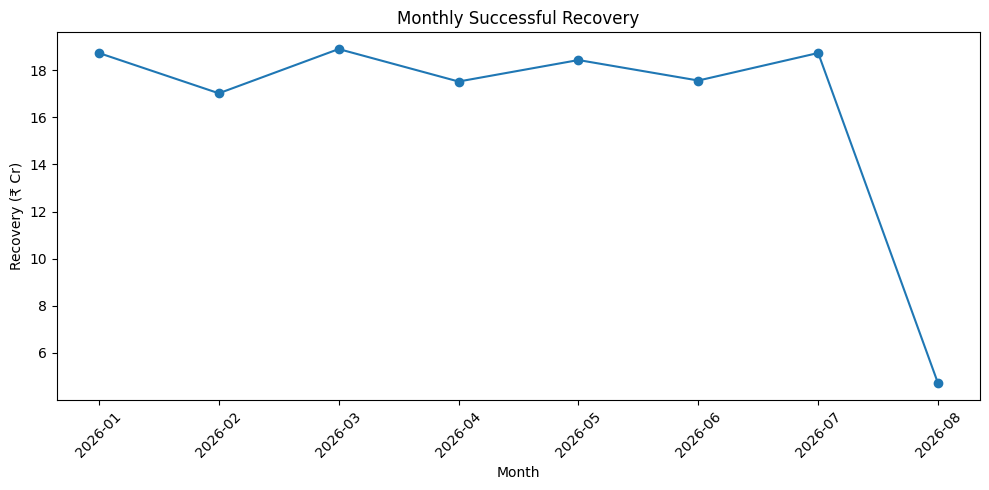

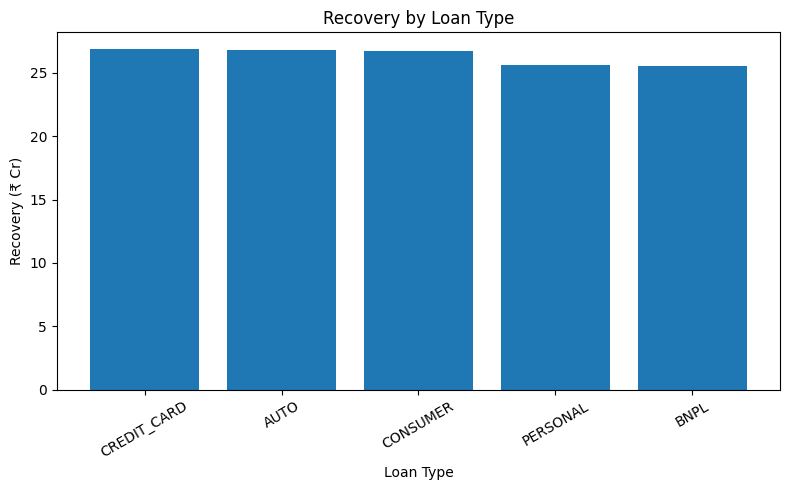

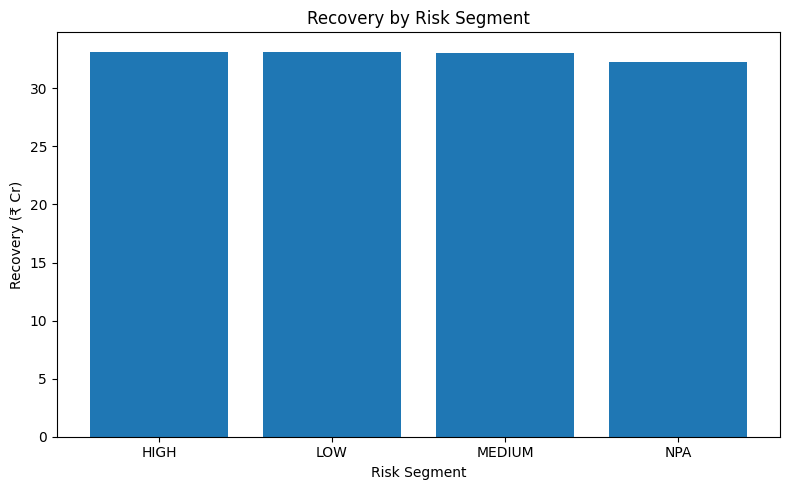

Dashboard figures saved to:
..\outputs\figures


In [56]:
# ============================================================
# EXECUTIVE DASHBOARD
# ============================================================

import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Monthly recovery
monthly_recovery = (
    payments_clean[
        payments_clean["payment_status"] == "SUCCESS"
    ]
    .assign(
        month=lambda x: pd.to_datetime(
            x["event_at"]
        ).dt.to_period("M").astype(str)
    )
    .groupby("month")["amount"]
    .sum()
    .reset_index(name="recovery")
)

# Loan type
loan_recovery = (
    payments_clean[
        payments_clean["payment_status"] == "SUCCESS"
    ]
    .merge(
        accounts[["account_id", "loan_type"]],
        on="account_id",
        how="left"
    )
    .groupby("loan_type")["amount"]
    .sum()
    .sort_values(ascending=False)
)

# Risk segment
risk_recovery = (
    payments_clean[
        payments_clean["payment_status"] == "SUCCESS"
    ]
    .merge(
        accounts[["account_id", "risk_segment"]],
        on="account_id",
        how="left"
    )
    .groupby("risk_segment")["amount"]
    .sum()
    .sort_values(ascending=False)
)

# ------------------------------------------------------------
# Create output folder
# ------------------------------------------------------------

figure_path = (
    DATA_PATH.parent.parent
    / "outputs"
    / "figures"
)

figure_path.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 1. Monthly recovery
# ------------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_recovery["month"],
    monthly_recovery["recovery"] / 1e7,
    marker="o"
)

plt.title("Monthly Successful Recovery")
plt.xlabel("Month")
plt.ylabel("Recovery (₹ Cr)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    figure_path / "monthly_recovery.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# 2. Recovery by loan type
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    loan_recovery.index,
    loan_recovery.values / 1e7
)

plt.title("Recovery by Loan Type")
plt.xlabel("Loan Type")
plt.ylabel("Recovery (₹ Cr)")
plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    figure_path / "recovery_by_loan_type.png",
    dpi=150
)

plt.show()

# ------------------------------------------------------------
# 3. Recovery by risk segment
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(
    risk_recovery.index,
    risk_recovery.values / 1e7
)

plt.title("Recovery by Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Recovery (₹ Cr)")
plt.tight_layout()

plt.savefig(
    figure_path / "recovery_by_risk.png",
    dpi=150
)

plt.show()

print("Dashboard figures saved to:")
print(figure_path)